In [13]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score
import mlflow
import mlflow.sklearn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [14]:
breast=load_breast_cancer()
breast

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [15]:
df=pd.DataFrame(breast.data,columns=breast.feature_names)
df['target']=breast.target

In [25]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [17]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

<Axes: >

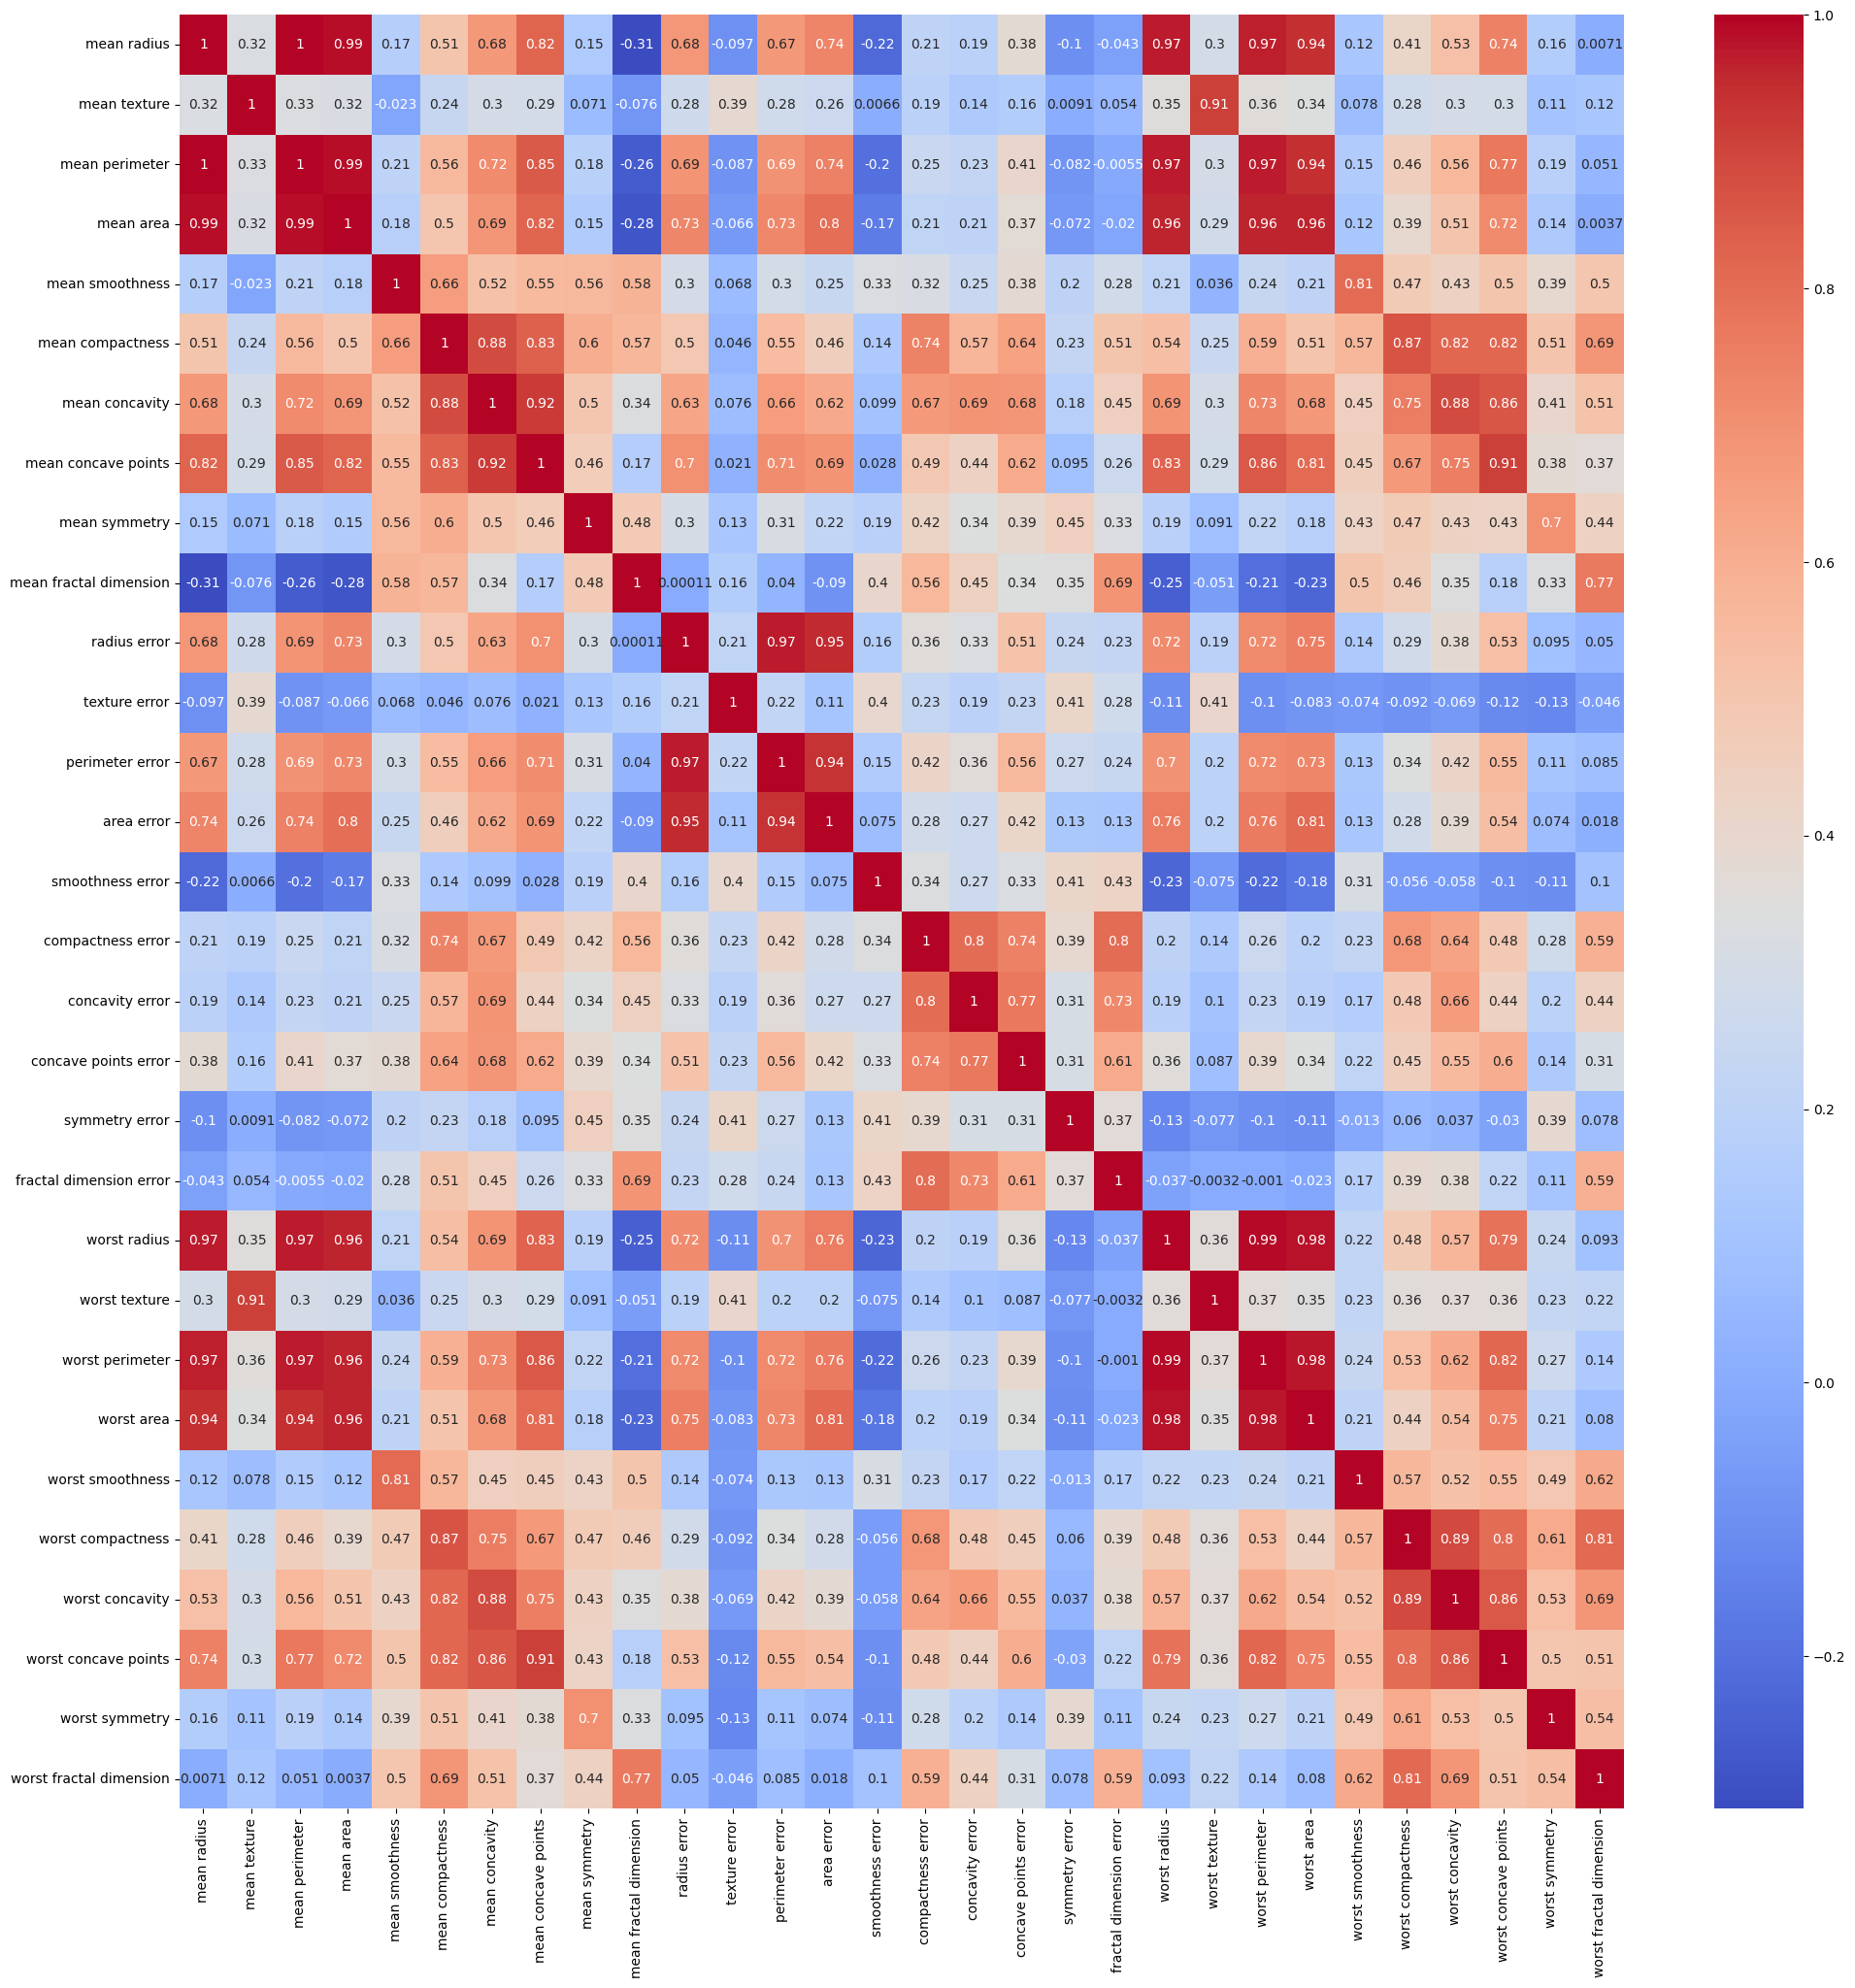

In [18]:
plt.figure(figsize=(24,24))
corr=df.drop('target',axis=1).corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")

In [19]:
x=df.drop('target',axis=1)
y=df['target']

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)

In [26]:
tree=DecisionTreeClassifier(random_state=42)
tree.fit(x_train,y_train)
y_pred=tree.predict(x_test)
acc=accuracy_score(y_pred,y_test)
acc

0.9473684210526315

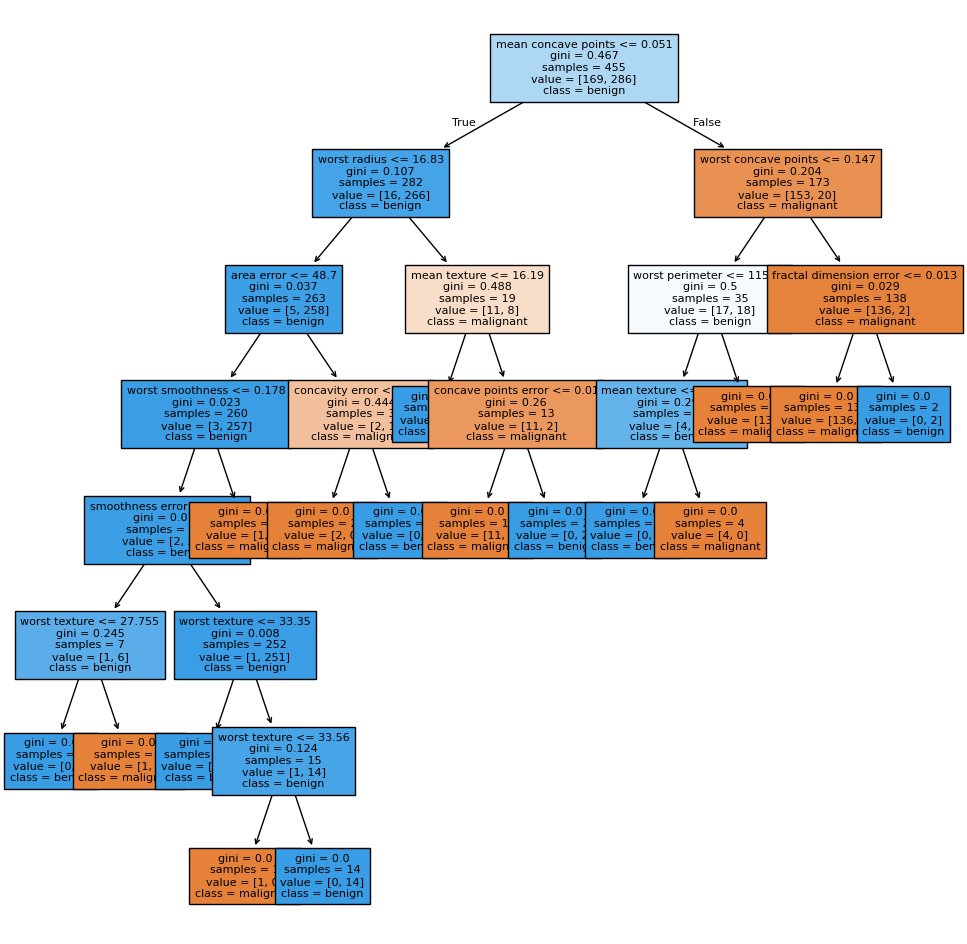

In [22]:
plt.figure(figsize=(12,12))
plot_tree(tree,feature_names=breast.feature_names,class_names=breast.target_names,filled=True,impurity=True,fontsize=8)
plt.show()

In [23]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Breast_Canser_Classification")

<Experiment: artifact_location='file:d:/macine learning/python/day8/mlruns/1', creation_time=1789412674755, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789412674755, lifecycle_stage='active', name='Breast_Canser_Classification', tags={}, trace_location=None, workspace='default'>

In [24]:
from sklearn.metrics import mean_squared_error, r2_score
with mlflow.start_run():

    # Train
    tree.fit(x_train, y_train)

    # Predict
    y_pred = tree.predict(x_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    

    # Log parameters
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)

    # Log metrics
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Log model
    mlflow.sklearn.log_model(
        tree,
        "model"
    )

    print("MSE:", mse)
    print("R2:", r2)

2026/09/14 22:16:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MSE: 0.05263157894736842
R2: 0.7759580740255486
